# Week 1 – Data Acquisition, Cleaning, and Preprocessing

**Objective:** Acquire, explore, clean, and preprocess the selected public dataset.

This notebook documents the complete data-quality workflow: initial exploration, missing values, duplicates, inconsistent values, outliers, data-type corrections, preprocessing, and export of the cleaned dataset.


## 1. Dataset Overview

The uploaded dataset contains **10,194 rows** and **24 columns**.

The original file supplied for this project has been saved as `data/raw_dataset.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
VIZ_DIR = Path("visualizations")
VIZ_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "raw_dataset.csv")
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10194, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Year_Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,2023-01
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,2023-01
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,2023-01
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,2023-01
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,2023-01


## 2. Initial Data Exploration

The first stage is to understand the structure of the dataset before making any changes. This helps prevent inappropriate cleaning decisions.


In [2]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Shape: (10194, 24)

Data types:


,dtype
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row ID,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
Order ID,10194,5111,US-2026-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,1242,2025-09-05,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Date,10194,1338,2024-12-16,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing-Value Analysis

Missing values are identified column by column. Numeric columns are candidates for median imputation, while categorical columns can use the mode when appropriate. The final treatment depends on the percentage of missing values and the meaning of each variable.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
display(missing_report)

if (missing > 0).any():
    missing_report[missing_report["missing_count"] > 0].plot(
        kind="bar", y="missing_count", figsize=(12,5), legend=False
    )
    plt.title("Missing Values by Column")
    plt.ylabel("Number of Missing Values")
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "missing_values.png", dpi=150)
    plt.show()


,missing_count,missing_percent
Row ID,0,0.0
Order ID,0,0.0
Month,0,0.0
Year,0,0.0
Profit,0,0.0
Discount,0,0.0
Quantity,0,0.0
Sales,0,0.0
Product Name,0,0.0
Sub-Category,0,0.0


## 4. Duplicate Records

Duplicate rows can distort counts and statistical summaries. Exact duplicate records are therefore identified and removed when they do not represent legitimate repeated observations.


In [4]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)


Duplicate rows before cleaning: 0
Shape after duplicate removal: (10194, 24)


## 5. Basic Consistency Checks

Column names are standardized and string values are stripped of unnecessary leading/trailing whitespace. Blank strings are treated as missing values.


In [5]:
# Standardize column names
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# Clean whitespace in text columns and convert blank strings to NaN
text_cols = df.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

print("Standardized columns:")
print(df.columns.tolist())


Standardized columns:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country_region', 'city', 'state_province', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'year_month']


## 6. Missing-Value Treatment

For numeric variables, the median is used because it is less sensitive to extreme values than the mean. For categorical variables, the most frequent category (mode) is used. This automated approach is appropriate for a general preprocessing workflow and should be reviewed against domain requirements.


In [6]:
# Numeric columns: median imputation
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical columns: mode imputation
categorical_cols = df.select_dtypes(include=["object", "string", "category"]).columns
for col in categorical_cols:
    if df[col].isna().any():
        mode = df[col].mode(dropna=True)
        if not mode.empty:
            df[col] = df[col].fillna(mode.iloc[0])

print("Remaining missing values:", int(df.isna().sum().sum()))


Remaining missing values: 0


## 7. Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method flags observations below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. Outliers are reported rather than automatically deleted because an extreme value may be a valid real-world observation.


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count
4,profit,1.7608,29.297925,27.537125,-39.544887,70.603612,1913
1,sales,17.2200,209.500000,192.280000,-271.200000,497.920000,1183
3,discount,0.0000,0.200000,0.200000,-0.300000,0.500000,874
2,quantity,2.0000,5.000000,3.000000,-2.500000,9.500000,175
0,row_id,2549.2500,7645.750000,5096.500000,-5095.500000,15290.500000,0
5,year,2024.0000,2026.000000,2.000000,2021.000000,2029.000000,0
6,month,5.0000,11.000000,6.000000,-4.000000,20.000000,0


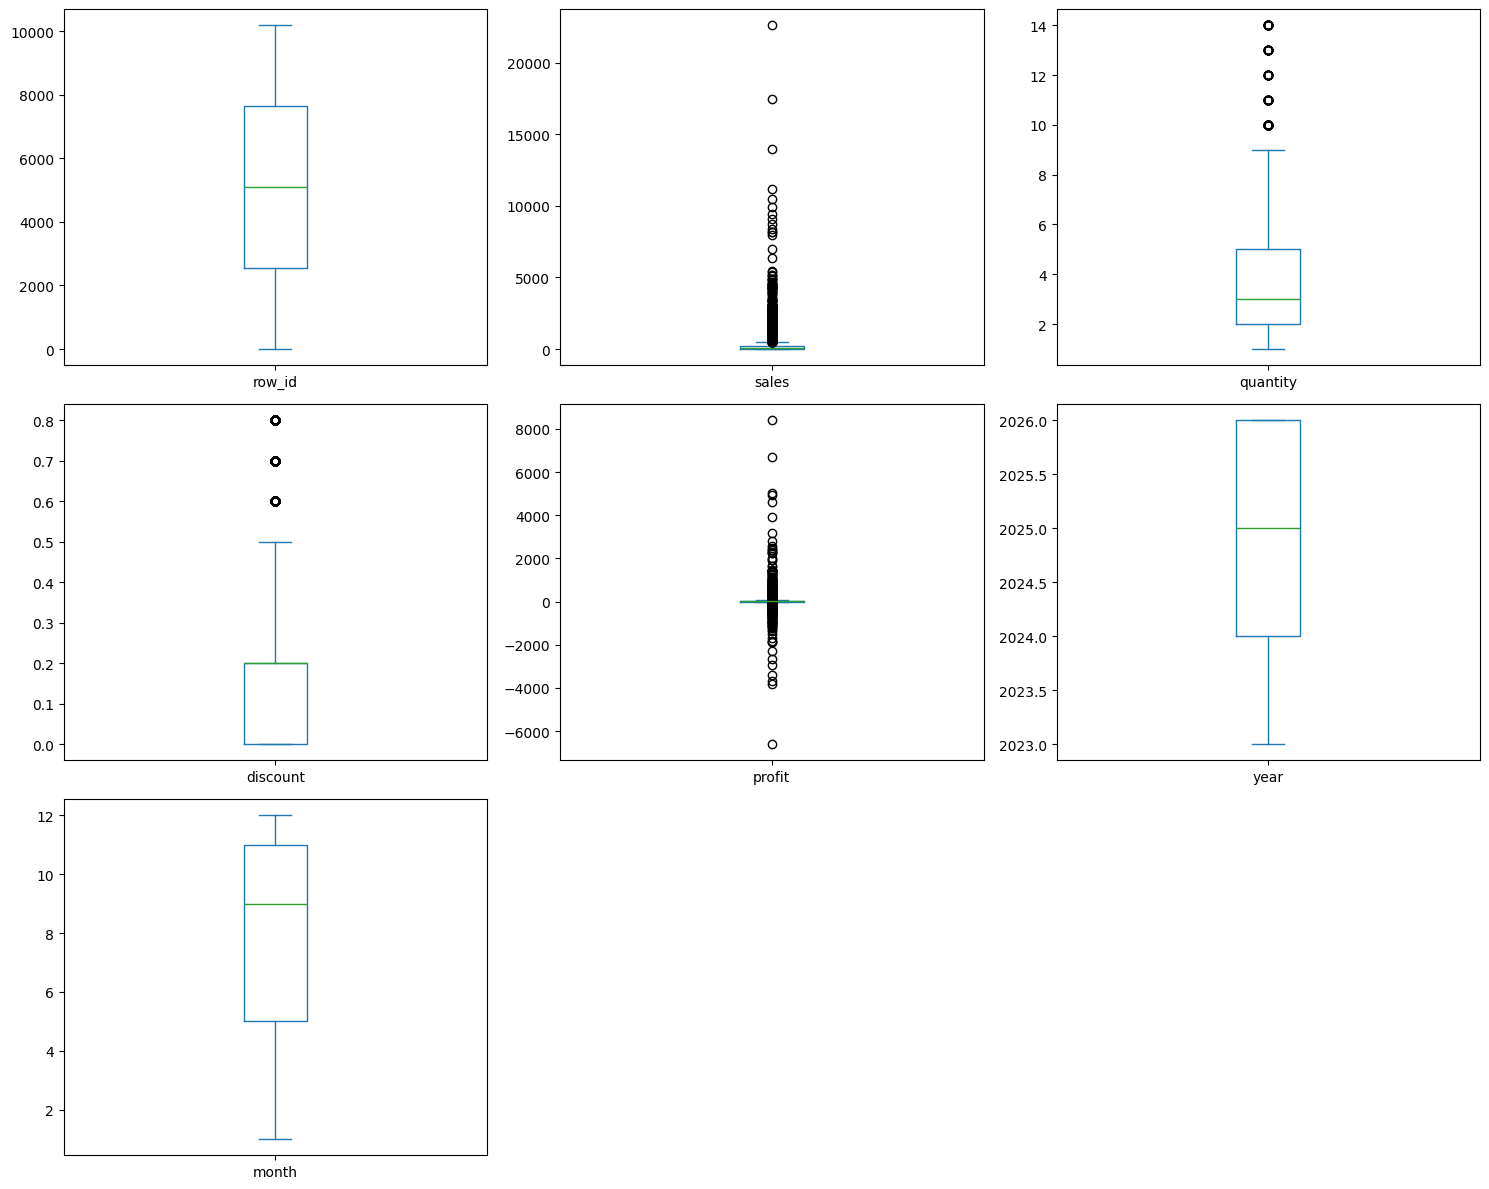

In [7]:
outlier_summary = []

for col in numeric_cols:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        count = 0
        lower, upper = q1, q3
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_summary.append([col, q1, q3, iqr, lower, upper, count])

outlier_report = pd.DataFrame(
    outlier_summary,
    columns=["column","q1","q3","iqr","lower_bound","upper_bound","outlier_count"]
)
display(outlier_report.sort_values("outlier_count", ascending=False))

if len(numeric_cols) > 0:
    df[numeric_cols].plot(kind="box", subplots=True, layout=(-1, 3), figsize=(15, 4*((len(numeric_cols)+2)//3)), sharex=False)
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "outliers_boxplots.png", dpi=150)
    plt.show()


## 8. Numeric Distribution Review

Histograms help identify skewness, unusual ranges, and variables that may need transformations in later analysis.


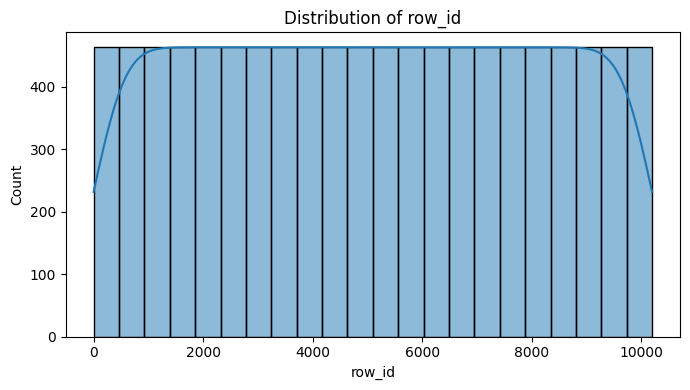

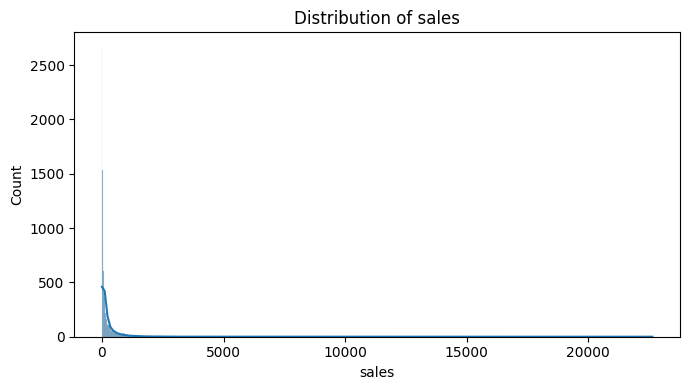

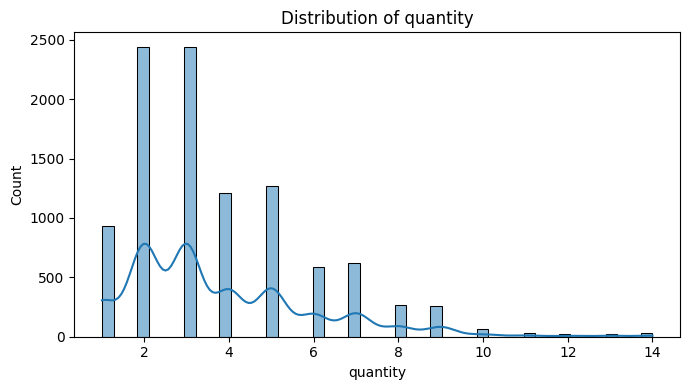

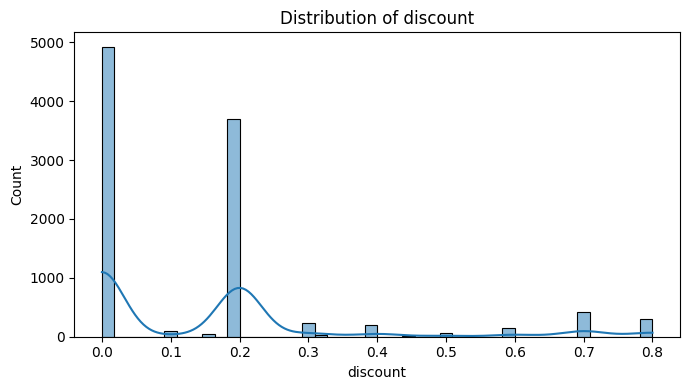

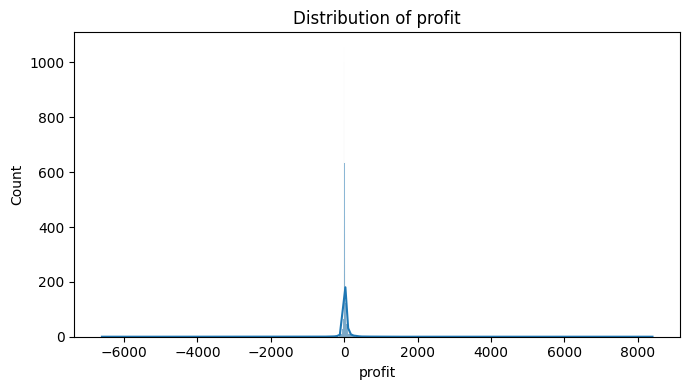

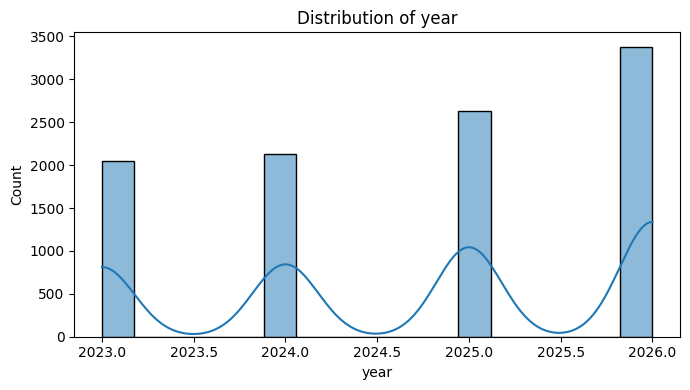

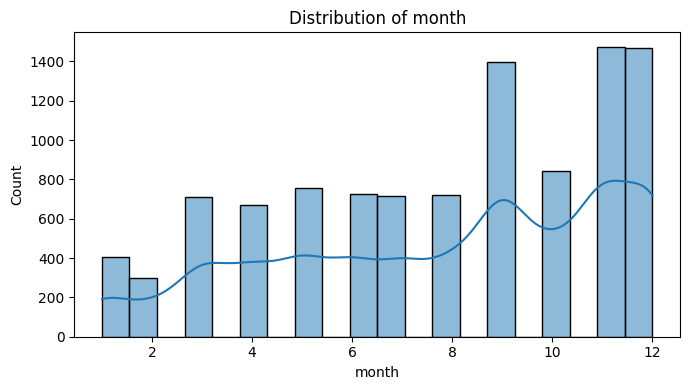

In [8]:
if len(numeric_cols) > 0:
    for col in numeric_cols:
        plt.figure(figsize=(7,4))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        safe = "".join(ch if ch.isalnum() else "_" for ch in col)
        plt.savefig(VIZ_DIR / f"distribution_{safe}.png", dpi=120)
        plt.show()


## 9. Final Data-Quality Check

After preprocessing, the dataset is checked again for missing values, duplicates, and data types. This provides evidence that the cleaning process produced a usable dataset.


In [9]:
print("Final shape:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())
print("Remaining missing values:", int(df.isna().sum().sum()))

display(df.head())
display(df.describe(include="all").T)


Final shape: (10194, 24)
Remaining duplicate rows: 0
Remaining missing values: 0


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,state_province,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,year,month,year_month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1,2023-01
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1,2023-01
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1,2023-01
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1,2023-01
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1,2023-01


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
row_id,10194.0,NaN,NaN,NaN,5097.5,2942.898656,1.0,2549.25,5097.5,7645.75,10194.0
order_id,10194,5111,US-2026-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,10194,1242,2025-09-05,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship_date,10194,1338,2024-12-16,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship_mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,10194,804,WB-21850,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,10194,800,William Brown,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,10194,3,Consumer,5281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Export Cleaned Dataset

The cleaned dataset is exported for future analysis. The raw dataset is preserved separately so that the cleaning process remains reproducible.


In [10]:
clean_path = DATA_DIR / "cleaned_dataset.csv"
df.to_csv(clean_path, index=False)

print(f"Cleaned dataset saved to: {clean_path}")


Cleaned dataset saved to: data\cleaned_dataset.csv


## 11. Challenges and Decisions

**Potential challenges addressed:**
- Missing observations were identified before treatment.
- Exact duplicate records were removed.
- Text formatting inconsistencies were reduced through whitespace and column-name standardization.
- Outliers were detected with the IQR method rather than blindly deleted.
- Numeric and categorical missing values were treated using different strategies.

**Impact on subsequent analysis:** Cleaning improves the reliability of descriptive statistics, visualizations, and machine-learning workflows. However, imputation can reduce natural variability, and outlier handling can change distributions. Therefore, preprocessing decisions should always be documented and validated against the dataset's domain.


## 12. Conclusion

The dataset was systematically inspected and transformed into a cleaner analytical version. The workflow is reproducible because the original data is retained and every major transformation is documented in this notebook.
